# 타이타닉 생존 데이터셋 분석

인터넷에서 타이타닉호 승객 데이터를 가져와서 데이터 클렌징을 수행하고,
pandas와 matplotlib을 이용해 다각도로 분석해본다.
마지막에는 남성과 여성의 생존율을 막대그래프로 시각화한다.

## 1. 라이브러리 불러오기 및 데이터 로딩

타이타닉 데이터셋은 GitHub에 공개된 CSV 파일(seaborn 프로젝트의 데이터)을 인터넷에서 직접 읽어온다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 인터넷 상의 타이타닉 데이터셋(seaborn 공식 저장소 CSV)을 직접 로딩
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
df = pd.read_csv(url)

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. 데이터 기본 정보 확인

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [3]:
# 결측치 개수 확인
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

## 3. 데이터 클렌징 (결측치 처리 및 불필요한 컬럼 정리)

- `deck` 컬럼: 결측치가 너무 많아 컬럼 자체를 제거
- `age` 컬럼: 중앙값으로 결측치 채움
- `embarked`, `embark_town` 컬럼: 최빈값으로 결측치 채움
- 중복 행 제거
- 분석에 크게 필요없는 중복 의미 컬럼(`alive`, `who`, `adult_male`, `class`) 중 일부 정리

In [4]:
df_clean = df.copy()

# 결측치가 많은 deck 컬럼 제거
if 'deck' in df_clean.columns:
    df_clean = df_clean.drop(columns=['deck'])

# age는 중앙값으로 대체
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# embarked, embark_town은 최빈값으로 대체
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

# 중복 행 제거
df_clean = df_clean.drop_duplicates()

# 인덱스 재정렬
df_clean = df_clean.reset_index(drop=True)

print('클렌징 후 결측치 현황:')
print(df_clean.isnull().sum())
print('\n클렌징 후 shape:', df_clean.shape)
df_clean.head()

클렌징 후 결측치 현황:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

클렌징 후 shape: (775, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## 4. 다각도 분석

### 4-1. 기본 통계량

In [5]:
df_clean.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
count,775.000000,775.000000,775,775.000000,775.000000,775.000000,775.000000,775,775,775,775,775,775,775
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,Southampton,no,True
freq,NaN,NaN,483,NaN,NaN,NaN,NaN,562,401,443,443,562,455,437
mean,0.412903,2.246452,NaN,29.581187,0.529032,0.420645,34.878403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.492674,0.853574,NaN,13.766359,0.990326,0.840565,52.408474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,1.000000,NaN,21.000000,0.000000,0.000000,8.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,15.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,36.000000,1.000000,1.000000,34.197900,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4-2. 객실 등급(Pclass)별 생존율

pclass
1    0.633333
2    0.506098
3    0.259352
Name: survived, dtype: float64


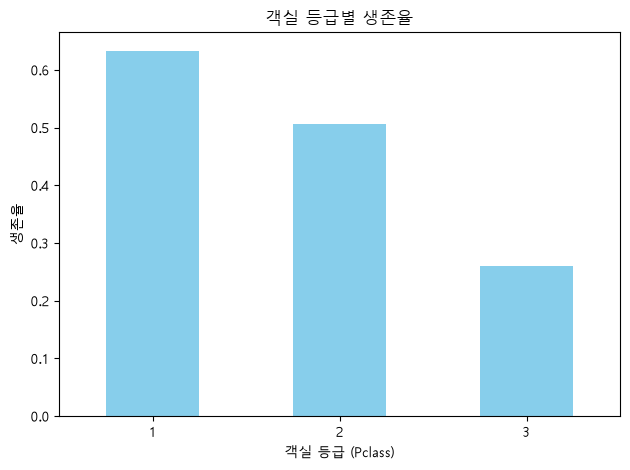

In [6]:
pclass_survival = df_clean.groupby('pclass')['survived'].mean()
print(pclass_survival)

pclass_survival.plot(kind='bar', color='skyblue', title='객실 등급별 생존율')
plt.xlabel('객실 등급 (Pclass)')
plt.ylabel('생존율')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4-3. 나이대별 생존율

age_group
0-9      0.606557
10-19    0.422680
20-29    0.368771
30-39    0.455128
40-49    0.386364
50-59    0.404255
60-69    0.333333
70+      0.142857
Name: survived, dtype: float64


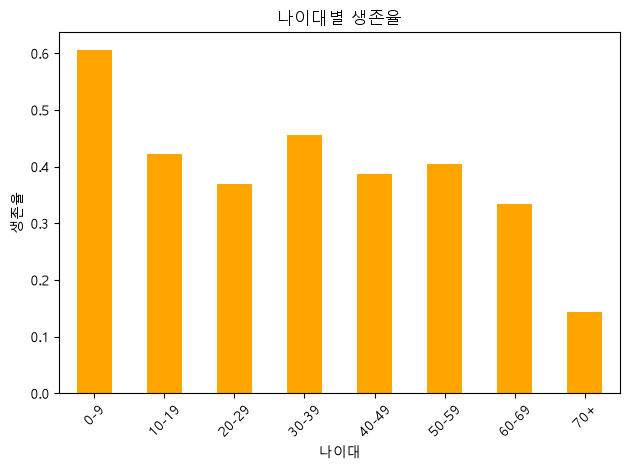

In [7]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 100]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)

age_survival = df_clean.groupby('age_group', observed=True)['survived'].mean()
print(age_survival)

age_survival.plot(kind='bar', color='orange', title='나이대별 생존율')
plt.xlabel('나이대')
plt.ylabel('생존율')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4-4. 탑승 항구(embark_town)별 생존율

embark_town
Cherbourg      0.580645
Queenstown     0.344828
Southampton    0.373665
Name: survived, dtype: float64


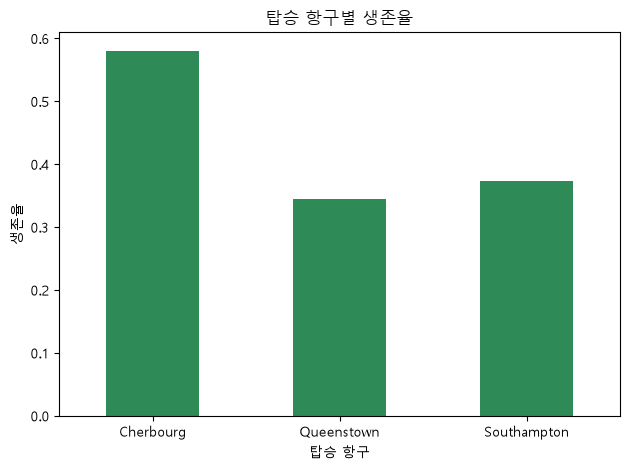

In [8]:
town_survival = df_clean.groupby('embark_town')['survived'].mean()
print(town_survival)

town_survival.plot(kind='bar', color='seagreen', title='탑승 항구별 생존율')
plt.xlabel('탑승 항구')
plt.ylabel('생존율')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4-5. 요금(fare)과 생존 여부의 관계

survived
0    24.022499
1    50.314142
Name: fare, dtype: float64


<Figure size 640x480 with 0 Axes>

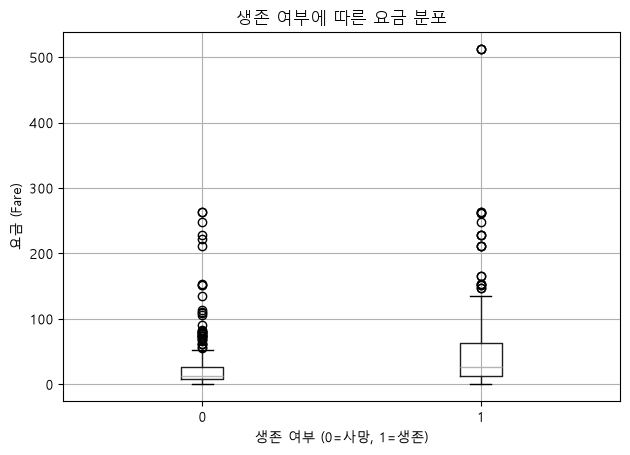

In [9]:
fare_by_survived = df_clean.groupby('survived')['fare'].mean()
print(fare_by_survived)

plt.figure()
df_clean.boxplot(column='fare', by='survived')
plt.title('생존 여부에 따른 요금 분포')
plt.suptitle('')
plt.xlabel('생존 여부 (0=사망, 1=생존)')
plt.ylabel('요금 (Fare)')
plt.tight_layout()
plt.show()

### 4-6. 상관관계 히트맵 (수치형 변수)

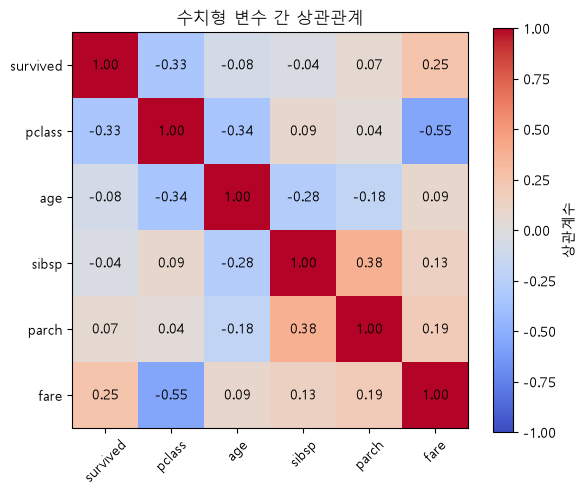

In [10]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='상관계수')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
plt.title('수치형 변수 간 상관관계')
plt.tight_layout()
plt.show()

## 5. 남성과 여성의 생존율 비교 (막대그래프)

성별 생존율:
sex
male      0.215321
female    0.739726
Name: survived, dtype: float64


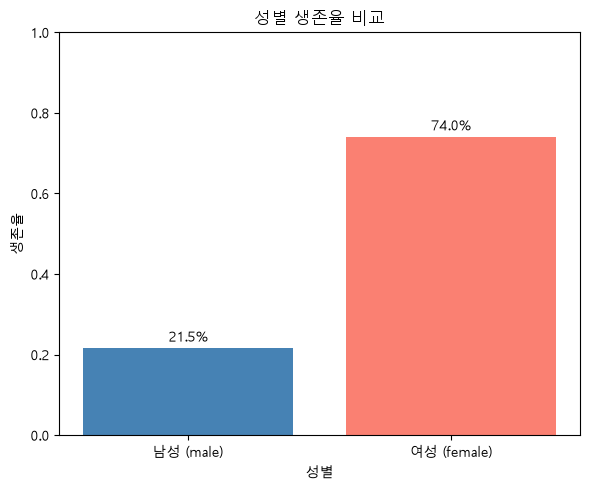

In [12]:
gender_survival = df_clean.groupby('sex')['survived'].mean().reindex(['male', 'female'])
print('성별 생존율:')
print(gender_survival)

plt.figure(figsize=(6, 5))
colors = ['steelblue', 'salmon']
bars = plt.bar(gender_survival.index, gender_survival.values, color=colors)

# 막대 위에 생존율(%) 텍스트 표시
for bar, rate in zip(bars, gender_survival.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{rate * 100:.1f}%', ha='center', va='bottom')

plt.title('성별 생존율 비교')
plt.xlabel('성별')
plt.ylabel('생존율')
plt.ylim(0, 1)
plt.xticks([0, 1], ['남성 (male)', '여성 (female)'])
plt.tight_layout()
plt.show()

## 6. 결론

- 여성의 생존율이 남성보다 확연히 높다.
- 객실 등급이 높을수록(1등급) 생존율이 높다.
- 요금을 많이 낸 승객일수록 생존율이 높은 경향이 있다.
- 나이대별로는 어린이의 생존율이 상대적으로 높은 편이다.